In [17]:
# ==========================
# 1. Imports
# ==========================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_curve,
                            auc, precision_recall_curve,f1_score, recall_score, precision_score)

In [18]:
# ==========================
# 2. Load data
# ==========================
train_path = "/kaggle/input/heartbeat/mitbih_train.csv"
test_path  = "/kaggle/input/heartbeat/mitbih_test.csv"

# Files are 187 columns: 186 features + 1 label at the end. [web:28]
train_df = pd.read_csv(train_path, header=None)
test_df  = pd.read_csv(test_path, header=None)

# Separate features and labels
X_train_full = train_df.iloc[:, :-1].values
y_train_full = train_df.iloc[:, -1].values

X_test_full  = test_df.iloc[:, :-1].values
y_test_full  = test_df.iloc[:, -1].values

In [19]:
# ==========================
# 3. Convert 5-class labels to binary
# Original labels in this dataset: 0,1,2,3,4.
# Here we treat:
#   0 -> Normal
#   1,2,3,4 -> Arrhythmia
# ==========================
normal_labels = [0]
y_train_bin = np.where(np.isin(y_train_full, normal_labels), 0, 1)
y_test_bin  = np.where(np.isin(y_test_full,  normal_labels), 0, 1)

# Optional: create a validation split from train for better practice
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_bin, test_size=0.2, random_state=42, stratify=y_train_bin)

In [20]:
# ==========================
# 4. Scale features
# ==========================
scaler = StandardScaler()
X_tr_scaled   = scaler.fit_transform(X_tr)
X_val_scaled  = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_full)

In [21]:
# ==========================
# 5. Train Random Forest classifier
# ==========================
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_tr_scaled, y_tr)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [22]:
# ==========================
# 6. Evaluate on test sets
# ==========================

y_test_pred = clf.predict(X_test_scaled)
test_acc    = accuracy_score(y_test_bin, y_test_pred)
test_cm     = confusion_matrix(y_test_bin, y_test_pred)
test_report = classification_report(y_test_bin, y_test_pred, target_names=['Normal', 'Arrhythmia'])

print("\n======================")
print("Test Accuracy:", test_acc)
print("\nTest Confusion Matrix:\n", test_cm)
print("\nTest Classification Report:\n", test_report)


Test Accuracy: 0.9768408551068883

Test Confusion Matrix:
 [[18089    29]
 [  478  3296]]

Test Classification Report:
               precision    recall  f1-score   support

      Normal       0.97      1.00      0.99     18118
  Arrhythmia       0.99      0.87      0.93      3774

    accuracy                           0.98     21892
   macro avg       0.98      0.94      0.96     21892
weighted avg       0.98      0.98      0.98     21892



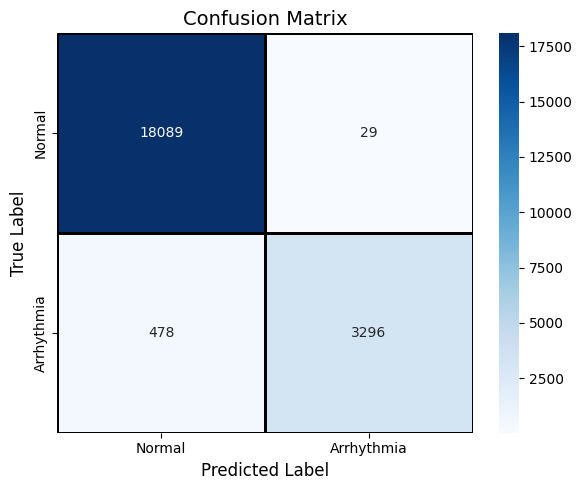

In [23]:
# Confusion Matrix (Improved)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test_bin, y_test_pred)

# Create a larger figure
plt.figure(figsize=(6, 5))

# Plot heatmap
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar=True,
            linewidths=1,
            linecolor='black',
            xticklabels=['Normal', 'Arrhythmia'],
            yticklabels=['Normal', 'Arrhythmia'])

# Labels and title
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)

# Improve layout
plt.tight_layout()
plt.show()

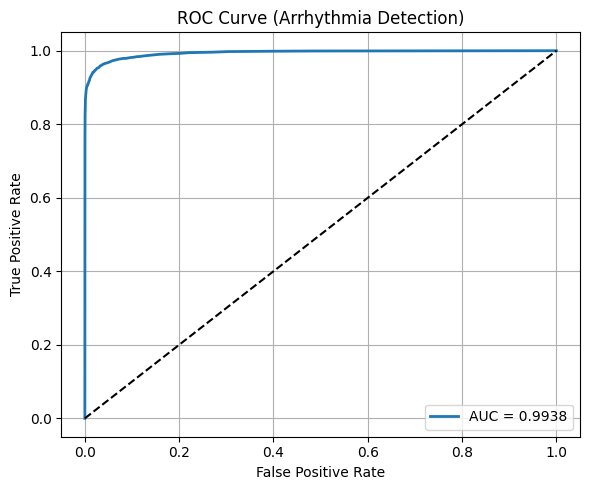

In [24]:
# ==========================
# 7. ROC Curve (Correct for your model)
# ==========================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability scores (IMPORTANT)
y_probs = clf.predict_proba(X_test_scaled)[:, 1]   # class 1 = Arrhythmia

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test_bin, y_probs)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')  # random baseline

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Arrhythmia Detection)')
plt.legend(loc='lower right')

plt.grid(True)
plt.tight_layout()
plt.show()

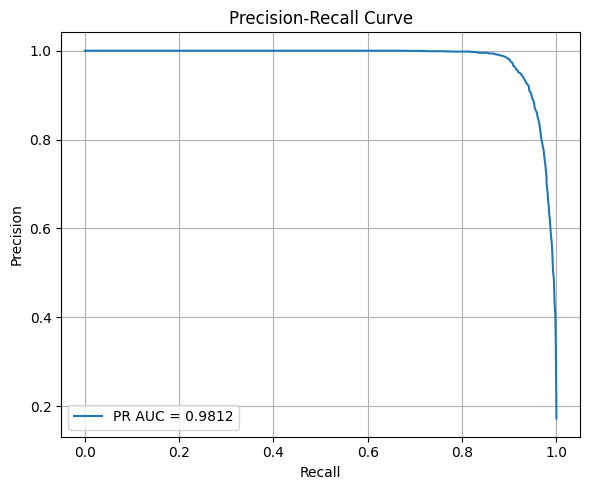

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Probabilities
y_probs = clf.predict_proba(X_test_scaled)[:, 1]

# Compute Precision-Recall
precision, recall, _ = precision_recall_curve(y_test_bin, y_probs)
pr_auc = average_precision_score(y_test_bin, y_probs)

# Plot
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.4f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

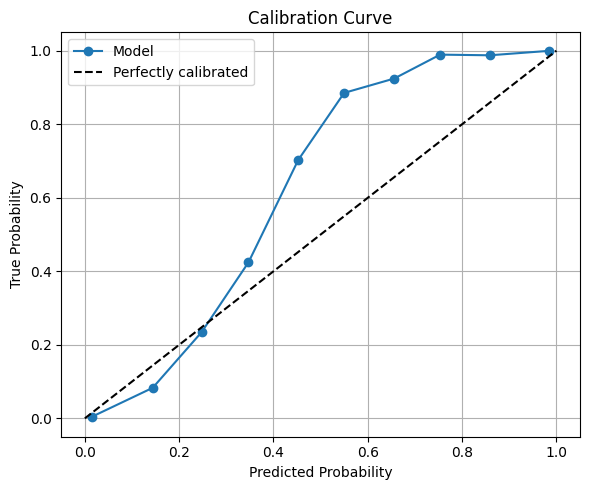

In [26]:
from sklearn.calibration import calibration_curve

y_probs = clf.predict_proba(X_test_scaled)[:, 1]

prob_true, prob_pred = calibration_curve(y_test_bin, y_probs, n_bins=10)

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0,1], [0,1], 'k--', label='Perfectly calibrated')

plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

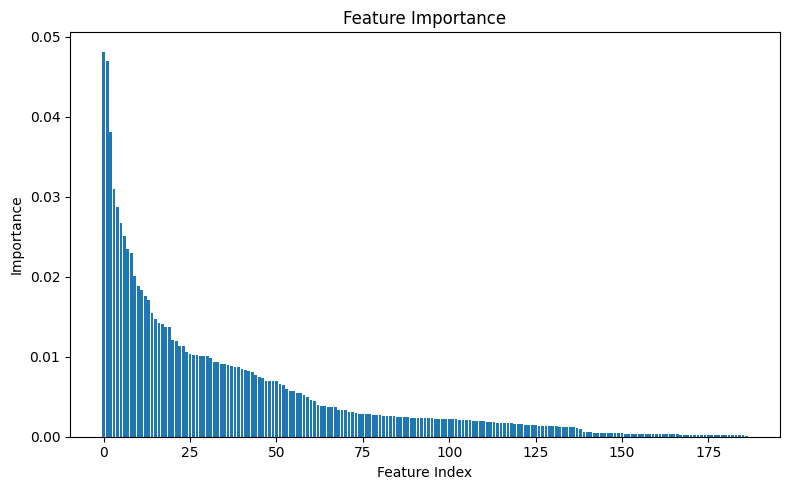

In [27]:
import pandas as pd
import numpy as np

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.title("Feature Importance")
plt.bar(range(len(importances)), importances[indices])

plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

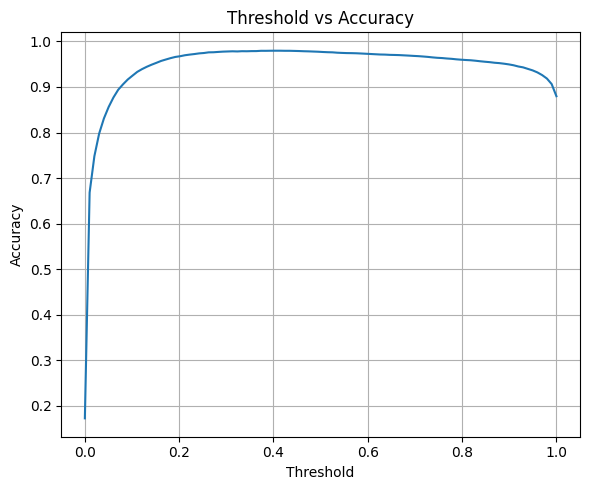

In [28]:
thresholds = np.linspace(0, 1, 100)
accuracies = []

y_probs = clf.predict_proba(X_test_scaled)[:, 1]

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    acc = (y_pred == y_test_bin).mean()
    accuracies.append(acc)

plt.figure(figsize=(6,5))
plt.plot(thresholds, accuracies)

plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Threshold vs Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()